## Loan Approval Classification - ML

In [8]:
%pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# load the dataset
df = pd.read_csv('../datasets/loan_data.csv')

# clear the leading/trailing spaces from the column headers
df.columns = df.columns.str.strip()

print("--- Dataset shape ---")
print(df.shape)

print("\n --- Column info --- ")
print(df.info())

print("\n --- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- First 5 Rows ---")
print(df.head())


--- Dataset shape ---
(45000, 14)

 --- Column info --- 
<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null 

In [10]:
# check the target balance, i.e, what fraction is approved vs not approved
print("\n--- Target Balance ---")
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True))


--- Target Balance ---
loan_status
0    35000
1    10000
Name: count, dtype: int64
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


/var/folders/gb/b7bv9wc95kn1v1dlm10t_g380000gn/T/ipykernel_39267/3262677482.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="loan_status", y="credit_score", palette="Set2", data=df)


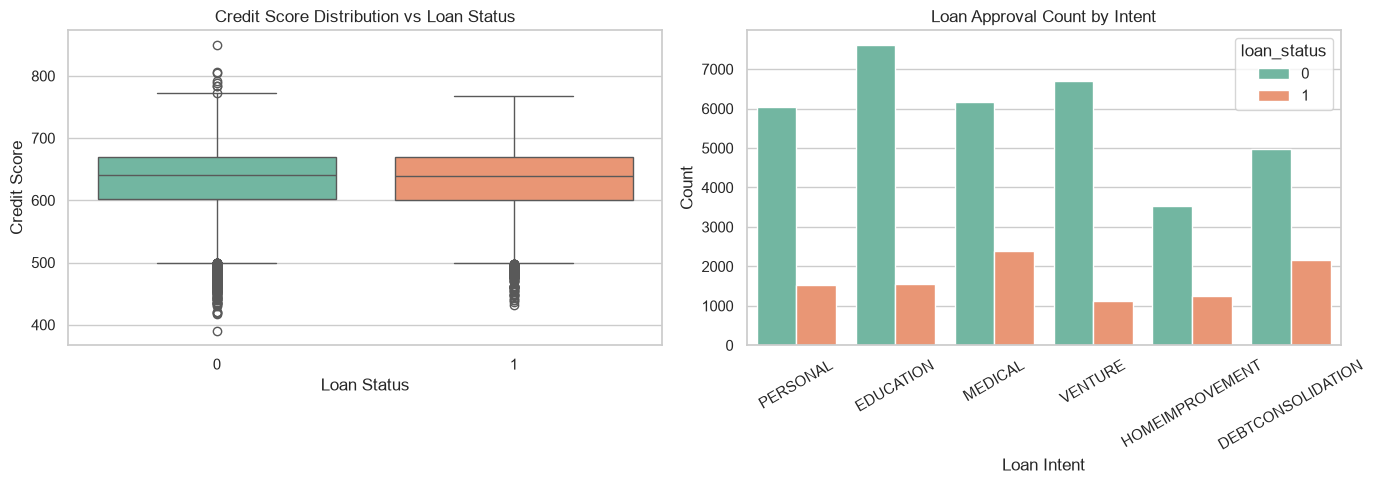

In [11]:
# set the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))


# plot 1: Credit Score vs Loan Approval
plt.subplot(1, 2, 1)
sns.boxplot(x="loan_status", y="credit_score", palette="Set2", data=df)
plt.title("Credit Score Distribution vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

# plot 2: Loan Intent vs approval status
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='loan_intent', hue='loan_status', palette='Set2')
plt.title('Loan Approval Count by Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.xticks(rotation=30) # so that the intents don't overlap ;)

plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

categorical_cols = [
    'person_gender', 
    'person_education', 
    'person_home_ownership', 
    'loan_intent', 
    'previous_loan_defaults_on_file'
]

# one hot encode -> sepearate columns of 0s and 1s
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# create a matrix X, having all vars, except the answer -> status column
X = df_encoded.drop(columns=['loan_status'])
y = df_encoded['loan_status'] # vector y having correct answer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #20:80 split
) 

scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) # mean-> standard deviation scaling -> transform the training data
X_test_scaled = scaler.transform(X_test) # transform test data using the same scaling


print("Preprocessing complete!!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")



Preprocessing complete!!
Training features shape: (36000, 22)
Testing features shape: (9000, 22)
